In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [7]:
df = pd.read_excel("heart_disease.xlsx")
df.head()

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


In [9]:
df.shape

(12, 2)

In [10]:
df.tail()

,age,Age in years
7,exang,exercise induced angina
8,oldpeak,ST depression induced by exercise relative to ...
9,slope,the slope of the peak exercise ST segment
10,thal,Thal
11,num,"target [0=no heart disease; 1,2,3,4 = stages o..."


In [12]:
df = pd.read_excel("heart_disease.xlsx", sheet_name="Heart_disease")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [13]:
df.shape

(908, 13)

In [14]:
df.dtypes

,0
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,bool
restecg,object
thalch,int64
exang,object
oldpeak,float64


In [15]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [16]:
df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)

/tmp/ipykernel_2258/4171898574.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)


In [17]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [18]:
X = df.drop('num', axis=1)
y = df['num']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [21]:
df.dtypes

,0
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,bool
restecg,object
thalch,int64
exang,object
oldpeak,float64


In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

In [24]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,bool
restecg,int64
thalch,int64
exang,int64
oldpeak,float64


In [25]:
X = df.drop('num', axis=1)
y = df['num']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [28]:
y_pred = model.predict((X_test))

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.73      0.74        89
           1       0.33      0.31      0.32        48
           2       0.31      0.41      0.35        22
           3       0.12      0.12      0.12        17
           4       0.00      0.00      0.00         6

    accuracy                           0.50       182
   macro avg       0.30      0.31      0.31       182
weighted avg       0.50      0.50      0.50       182



In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[65 15  5  3  1]
 [16 15 10  7  0]
 [ 2  5  9  5  1]
 [ 3  9  2  2  1]
 [ 1  2  3  0  0]]


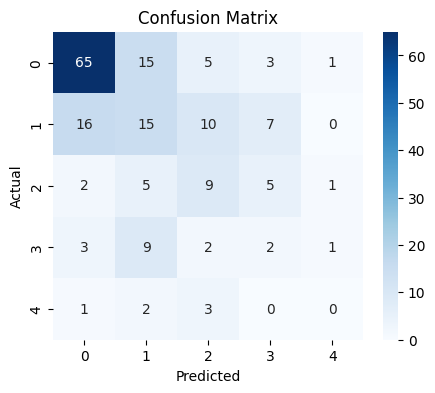

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

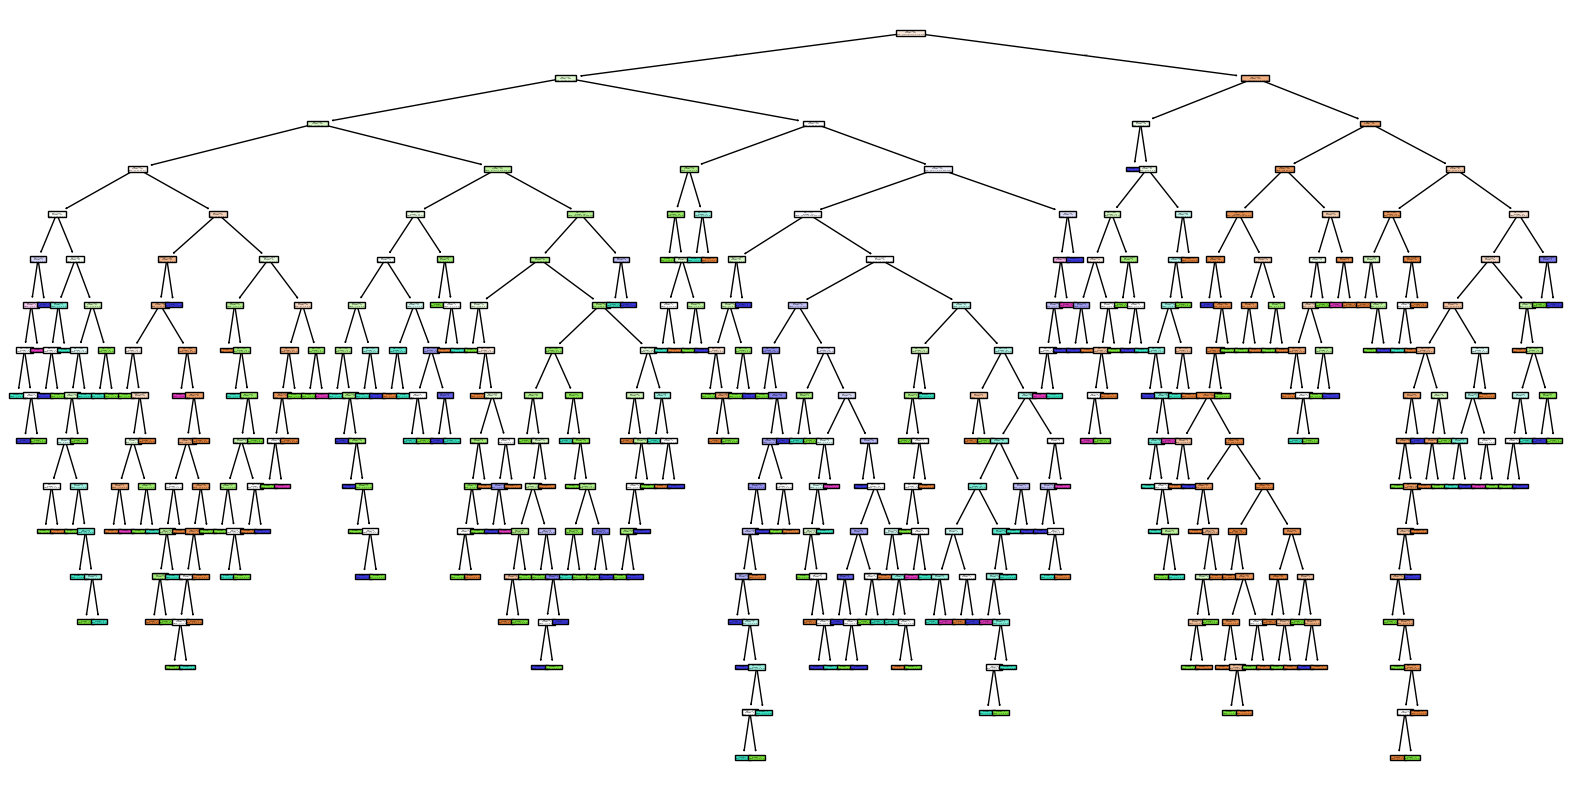

In [33]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X.columns)
plt.show()

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [3, 5, 7, 10, None]

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print("Max Depth:", depth, " Accuracy:", round(acc, 3))

Max Depth: 3  Accuracy: 0.571
Max Depth: 5  Accuracy: 0.538
Max Depth: 7  Accuracy: 0.538
Max Depth: 10  Accuracy: 0.56
Max Depth: None  Accuracy: 0.5


Strengths of Decision Tree

* Easy to understand and interpret.
* Works with both numerical and categorical data.
* No feature scaling is required.
* Can capture non-linear relationships.

Weaknesses of Decision Tree

* Can overfit on training data.
* Sensitive to small changes in data.
* Deep trees become complex.
* Lower accuracy than ensemble methods in some cases.

Real-world Applications

* Heart disease prediction
* Medical diagnosis
* Loan approval
* Fraud detection
* Customer churn prediction

Interview Questions

1. What are some common hyperparameters of Decision Tree models, and how do they affect performance?

Answer:

* max_depth: Controls tree depth and helps prevent overfitting.
* min_samples_split: Minimum samples required to split a node.
* min_samples_leaf: Minimum samples required in a leaf node.
* criterion: Measures split quality (gini or entropy).

2. What is the difference between Label Encoding and One-Hot Encoding?

Answer:

* Label Encoding: Converts categories into numbers (e.g., Male=0, Female=1).
* One-Hot Encoding: Creates a separate binary column for each category.